#preprocessing

In [1]:
#database installation
!pip -q install opendatasets
from pathlib import Path
import opendatasets as od

RAW = Path("/content/data"); RAW.mkdir(parents=True, exist_ok=True)
od.download("https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated",
            data_dir=str(RAW/"plant_village_updated"))
print("Ready at:", RAW/"plant_village_updated")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rahfhs
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated


100%|██████████| 1.00G/1.00G [00:00<00:00, 1.66GB/s]



Ready at: /content/data/plant_village_updated


In [2]:
#  Total number of images
from pathlib import Path
import os, shutil, re, numpy as np

# # Root dataset directory
ROOT = Path("/content/data/plant_village_updated")
assert ROOT.exists(), f"المجلد غير موجود: {ROOT}"
# Detects when the dataset resides inside a single nested folder
subdirs = [d for d in ROOT.iterdir() if d.is_dir()]
if len(subdirs) == 1 and not (ROOT/"train").exists():
    ROOT = subdirs[0]
print("Using dataset root:", ROOT)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image(p: Path):
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean_text(s: str):
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

#  Unified output directory
UNIFIED = ROOT.parent / (ROOT.name + "_unified")
if UNIFIED.exists():
    shutil.rmtree(UNIFIED)
for sp in ["train","val","test"]:
    (UNIFIED/sp).mkdir(parents=True, exist_ok=True)

# Possible split aliases
SPLIT_ALIASES = {
    "train": ["train","Train","TRAIN","training","Training"],
    "val":   ["val","Val","valid","Valid","validation","Validation"],
    "test":  ["test","Test","TEST","testing","Testing"],
}

rng = np.random.default_rng(42)

def copy_images(src_files, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img in src_files:
        tgt = dst_dir / img.name
        # إن وجد اسم مكرر، ضف لاحقة
        if tgt.exists():
            stem, suf = tgt.stem, tgt.suffix
            k = 1
            while (dst_dir / f"{stem}_{k}{suf}").exists():
                k += 1
            tgt = dst_dir / f"{stem}_{k}{suf}"
        shutil.copy2(img, tgt)

# Process each crop category
crops = [d for d in ROOT.iterdir() if d.is_dir()]
total_copied = 0
for crop in crops:
    crop_name = clean_text(crop.name)

    # Detect if crop contains predefined train/val/test folders
    found_split = False
    split_dirs = {}
    for split_key, aliases in SPLIT_ALIASES.items():
        for name in aliases:
            cand = crop / name
            if cand.exists():
                split_dirs[split_key] = cand
                found_split = True
                break

    if found_split:
        # Use existing split structure
        for split_key, split_dir in split_dirs.items():
            for disease_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
                disease_name = clean_text(disease_dir.name)
                class_name = f"{crop_name} - {disease_name}"
                files = [p for p in disease_dir.rglob("*") if is_image(p)]
                copy_images(files, UNIFIED / split_key / class_name)
                total_copied += len(files)
    else:
        #  No predefined split → apply manual 70/15/15 split
        disease_dirs = [d for d in crop.iterdir() if d.is_dir()]
        for disease_dir in disease_dirs:
            disease_name = clean_text(disease_dir.name)
            class_name = f"{crop_name} - {disease_name}"
            files = [p for p in disease_dir.rglob("*") if is_image(p)]
            if not files:
                continue
            rng.shuffle(files)
            n = len(files)
            n_train = int(n * 0.70)
            n_val   = int(n * 0.15)
            n_test  = n - n_train - n_val
            splits = {
                "train": files[:n_train],
                "val"  : files[n_train:n_train+n_val],
                "test" : files[n_train+n_val:]
            }
            for split_key, group in splits.items():
                copy_images(group, UNIFIED / split_key / class_name)
            total_copied += n

print("Unified dataset built at:", UNIFIED)
print("Total copied images:", total_copied)


Using dataset root: /content/data/plant_village_updated/plant-village-dataset-updated
Unified dataset built at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total copied images: 67118


In [3]:
# Total number of images in train, val, and test
# Listing all class names for each crop

from collections import defaultdict
import pandas as pd

# 1- Automatically determine the dataset root (either DATA_DIR or UNIFIED)
ROOT = None
for cand in [globals().get("DATA_DIR"), globals().get("UNIFIED")]:
    if cand is None:
        continue
    cand = Path(cand)
    if (cand/"train").exists():
        ROOT = cand
        break
assert ROOT is not None, "حددي ROOT: إما DATA_DIR (من resplit) أو UNIFIED (من التوحيد) ويحتوي مجلد train/."

#2- Helper functions
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def count_images_dir(d: Path) -> int:
    return sum(1 for p in d.rglob("*") if is_image(p))

#3- Determine available splits based on folder structure
splits = ["train","val"] + (["test"] if (ROOT/"test").exists() else [])

# 4- Calculations for each class in the format "Crop - Disease" + grouping by crop
by_crop = defaultdict(list)
rows = []

train_class_dirs = sorted([d for d in (ROOT/"train").iterdir() if d.is_dir()], key=lambda x: x.name)

for d in train_class_dirs:
    name = d.name
    if " - " in name:
        crop_name, disease = name.split(" - ", 1)
    else:
        parts = name.split()
        crop_name, disease = parts[0], " ".join(parts[1:]) if len(parts)>1 else "(Unknown)"

    counts = {s: count_images_dir(ROOT/s/name) for s in splits}
    counts["total"] = sum(counts.values())

    by_crop[crop_name].append((disease, name, counts))
    rows.append({
        "crop": crop_name,
        "class_name": name,
        "disease": disease,
        **{s: counts[s] for s in splits},
        "total": counts["total"]
    })

#5- Print detailed class breakdown per crop
print("\n Classes by crop (with image counts):")
for crop_name in sorted(by_crop.keys()):
    items = sorted(by_crop[crop_name], key=lambda x: x[0])
    crop_tot = {s: sum(it[2][s] for it in items) for s in splits}
    crop_tot["total"] = sum(crop_tot.values())
    header = " | ".join([f"{s}={crop_tot[s]}" for s in splits] + [f"total={crop_tot['total']}"])
    print(f"\n{crop_name} ({len(items)} classes) [{header}]")
    for i, (dz, class_name, cnts) in enumerate(items, 1):
        line = " | ".join([f"{s}:{cnts[s]}" for s in splits] + [f"Σ:{cnts['total']}"])
        print(f"  {i:2d}. {dz} -> {line}")

# 6- save as result CSV
df = pd.DataFrame(rows)
csv_path = ROOT / "class_counts_by_crop.csv"
df.to_csv(csv_path, index=False)
print("\n Saved counts table to:", csv_path)

# 7- Compute overall image totals per split and the global total
totals = {s: count_images_dir(ROOT/s) for s in splits}
grand_total = sum(totals.values())
print("\n Totals (images per split):")
for s in splits:
    print(f"  {s:<5} = {totals[s]}")
print(f"  total = {grand_total}")



 Classes by crop (with image counts):

Apple (4 classes) [train=7771 | val=1747 | test=196 | total=9714]
   1. Apple Scab -> train:2016 | val:453 | test:51 | Σ:2520
   2. Black Rot -> train:1987 | val:447 | test:50 | Σ:2484
   3. Cedar Apple Rust -> train:1760 | val:396 | test:44 | Σ:2200
   4. Healthy -> train:2008 | val:451 | test:51 | Σ:2510

Bell Pepper (2 classes) [train=3901 | val=877 | test=98 | total=4876]
   1. Bacterial Spot -> train:1913 | val:430 | test:48 | Σ:2391
   2. Healthy -> train:1988 | val:447 | test:50 | Σ:2485

Cherry (2 classes) [train=3509 | val=788 | test=89 | total=4386]
   1. Healthy -> train:1826 | val:410 | test:46 | Σ:2282
   2. Powdery Mildew -> train:1683 | val:378 | test:43 | Σ:2104

Corn (Maize) (4 classes) [train=7316 | val=1645 | test=188 | total=9149]
   1. Cercospora Leaf Spot -> train:1642 | val:369 | test:45 | Σ:2056
   2. Common Rust -> train:1907 | val:429 | test:48 | Σ:2384
   3. Healthy -> train:1859 | val:418 | test:47 | Σ:2324
   4. North

In [4]:
#  Unifing / Renaming

from pathlib import Path
import shutil, re
from collections import Counter
import pandas as pd

# --------General settings (paths and image extensions)--------
SRC = Path("/content/data/plant_village_updated/plant-village-dataset-updated")  # Source
DST = SRC.parent / (SRC.name + "_unified")                                      # Output folder
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
SPLITS = {"train","val","test"}  # إن وُجدت

DST.mkdir(parents=True, exist_ok=True)

def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean(s: str) -> str:
    s = s.replace("_", " ")
    s = re.sub(r"[()]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def split_plant_disease(name: str):
    """Extract plant and disease labels from folder names."""
    n = clean(name)

    # Patterns 'Plant - Disease'
    if " - " in n:
        plant, disease = n.split(" - ", 1)
        return clean(plant), clean(disease)


    plants = [
        "Apple","Bell Pepper","Cherry","Corn (Maize)","Corn Maize","Grape",
        "Peach","Potato","Strawberry","Tomato"
    ]
    for plant in plants:
        if n.lower().startswith(plant.lower()):
            disease = clean(n[len(plant):])
            plant = "Corn (Maize)" if plant.lower() in {"corn maize","corn (maize)"} else plant
            return plant, disease

    return None, None

def iter_leaf_folders(base: Path):

    """Locate image folders and infer their labels."""

    for plant_dir in base.iterdir():
        if not plant_dir.is_dir():
            continue

        # Case: "Plant - Disease"
        p_plant, p_dis = split_plant_disease(plant_dir.name)
        if p_plant and p_dis and any(is_image(x) for x in plant_dir.rglob("*")):
            yield (p_plant, p_dis, plant_dir)
            continue


        plant_name = clean(plant_dir.name)


        subdirs = [d for d in plant_dir.iterdir() if d.is_dir()]
        if not subdirs: # images directly inside plant folder

            if any(is_image(x) for x in plant_dir.iterdir()):
                yield (plant_name, "", plant_dir)
            continue


        split_dirs = [d for d in subdirs if d.name.lower() in SPLITS]
        if split_dirs: # train/val/test structure
            for sp in split_dirs:
                for disease_dir in [d for d in sp.iterdir() if d.is_dir()]:
                    if any(is_image(x) for x in disease_dir.iterdir()):
                        yield (plant_name, clean(disease_dir.name), disease_dir)
            continue

       # plant/disease structure
        for disease_dir in subdirs:
            if any(is_image(x) for x in disease_dir.iterdir()):
                # ممكن يكون disease_dir اسمه "Plant - Disease"
                pp, dd = split_plant_disease(disease_dir.name)
                if pp and dd:
                    yield (pp, dd, disease_dir)
                else:
                    yield (plant_name, clean(disease_dir.name), disease_dir)

def unique_copy(src: Path, dst_dir: Path):

    """Copy image while preventing filename conflicts."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    name = src.name
    target = dst_dir / name
    if not target.exists():
        shutil.copy2(src, target)
        return target

    stem, suf = src.stem, src.suffix
    k = 1
    while True:
        cand = dst_dir / f"{stem}_{k}{suf}"
        if not cand.exists():
            shutil.copy2(src, cand)
            return cand
        k += 1

# -------- Execution --------
counts = Counter()
mappings = []   # (plant, disease, src_dir, dst_class, num_imgs)
unmatched = []

for plant, disease, src_dir in iter_leaf_folders(SRC):

    plant = clean(plant) if plant else ""
    disease = clean(disease) if disease else "Healthy"
    dst_class = f"{plant} {disease}".strip()
    dst_class = re.sub(r"\s+", " ", dst_class)

    n_before = counts[dst_class]
    for p in src_dir.iterdir():
        if is_image(p):
            unique_copy(p, DST / dst_class)
            counts[dst_class] += 1

    n_new = counts[dst_class] - n_before
    mappings.append((plant, disease, str(src_dir), dst_class, n_new))


    if not plant or dst_class.lower() in {"", "healthy"}:
        unmatched.append((plant or "?", disease or "?", str(src_dir)))

# -------- Reporting --------
print(f"Unified dataset created at: {DST}")
print(f"Total classes: {len(counts)}")
print(f" Total images: {sum(counts.values())}\n")

print("Classes & counts:")
for cls in sorted(counts):
    print(f"- {cls}: {counts[cls]}")


df = pd.DataFrame(mappings, columns=["plant","disease","src_dir","dst_class","copied_images"])
csv_path = DST / "unify_report.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\n Saved mapping report: {csv_path}")

if unmatched:
    print("\n Unmatched/weakly parsed entries (check and rerun if needed):")
    for plant, disease, src in unmatched[:30]:
        print(f"- plant='{plant}' disease='{disease}' from: {src}")
    if len(unmatched) > 30:
        print(f"... and {len(unmatched)-30} more")

Unified dataset created at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total classes: 29
 Total images: 67111

Classes & counts:
- Apple Apple Scab: 2520
- Apple Black Rot: 2484
- Apple Cedar Apple Rust: 2200
- Apple Healthy: 2510
- Bell Pepper Bacterial Spot: 2391
- Bell Pepper Healthy: 2485
- Cherry Healthy: 2282
- Cherry Powdery Mildew: 2104
- Corn Maize Cercospora Leaf Spot: 2052
- Corn Maize Common Rust: 2384
- Corn Maize Healthy: 2324
- Corn Maize Northern Leaf Blight: 2385
- Grape Black Rot: 2360
- Grape Esca Black Measles: 2400
- Grape Healthy: 2115
- Grape Leaf Blight: 2152
- Peach Bacterial Spot: 2297
- Peach Healthy: 2160
- Potato Early Blight: 2424
- Potato Healthy: 2280
- Potato Late Blight: 2424
- Strawberry Healthy: 2280
- Strawberry Leaf Scorch: 2218
- Tomato Bacterial Spot: 2127
- Tomato Early Blight: 2400
- Tomato Healthy: 2407
- Tomato Late Blight: 2314
- Tomato Septoria Leaf Spot: 2181
- Tomato Yellow Leaf Curl Virus: 2451

 Saved mapp

In [5]:
# Remove Duplicates
# ===== Remove Duplicates (phash) – fixed & safe =====
!pip -q install imagehash
from pathlib import Path
from PIL import Image, ImageFile
import imagehash, pandas as pd, shutil, collections, os

# 0) Settings
ImageFile.LOAD_TRUNCATED_IMAGES = True   # بعض الصور تكون ناقصة
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

# 1) Paths + Options
DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")
assert (DATA_DIR/"train").exists(), f"DATA_DIR غير موجود أو لا يحوي train: {DATA_DIR}"

REPORT_ONLY       = False
PREFER_SPLIT_KEEP = "train"

TRASH_DIR  = DATA_DIR.parent / (DATA_DIR.name + "_duplicates_trash")
REPORTS    = DATA_DIR / "_reports"
TRASH_DIR.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

# 2) Compute phash inside each split
def phashes_in_split(split: str):
    base = DATA_DIR / split
    hmap = collections.defaultdict(list)     # hash -> [paths]
    if not base.exists():
        return hmap
    for p in base.rglob("*"):
        if not is_image(p):
            continue
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                h = str(imagehash.phash(im))
            hmap[h].append(p)
        except Exception as e:

            pass
    return hmap

splits_present = [s for s in ["train","val","test"] if (DATA_DIR/s).exists()]
h_by_split     = {s: phashes_in_split(s) for s in splits_present}

# 3) Duplicates within a single split
dups_within_rows = []
for s in splits_present:
    for h, paths in h_by_split[s].items():
        if len(paths) > 1:
            for p in paths:
                dups_within_rows.append([s, h, str(p)])

# 4) Duplicates across splits
h_sets = {s: set(h_by_split[s].keys()) for s in splits_present}
dups_across_rows, pairs = [], []
if "train" in h_sets and "val"  in h_sets: pairs.append(("train","val"))
if "train" in h_sets and "test" in h_sets: pairs.append(("train","test"))
if "val"   in h_sets and "test" in h_sets: pairs.append(("val","test"))

for a, b in pairs:
    inter = h_sets[a] & h_sets[b]
    for h in inter:
        for p in h_by_split[a][h]:
            dups_across_rows.append([a, b, h, str(p)])
        for p in h_by_split[b][h]:
            dups_across_rows.append([a, b, h, str(p)])

# 5) Save reports
df_within = pd.DataFrame(dups_within_rows, columns=["split","phash","path"])
df_across = pd.DataFrame(dups_across_rows, columns=["split_a","split_b","phash","path"])
csv_within = REPORTS / "duplicates_within_split.csv"
csv_across = REPORTS / "duplicates_across_splits.csv"
if not df_within.empty: df_within.to_csv(csv_within, index=False)
if not df_across.empty: df_across.to_csv(csv_across, index=False)
print(f"داخل التقسيم (صفوف): {len(df_within)} | بين التقسيمات (صفوف): {len(df_across)}")
print("Saved:", (csv_within if not df_within.empty else "-"), "|",
               (csv_across if not df_across.empty else "-"))

# 6) Move duplicates to trash directory
def unique_in_trash(p: Path) -> Path:
    """أعطِ اسمًا غير مصطدم في TRASH_DIR مبنيًا على اسم الملف الأصلي"""
    stem, suf = p.stem, p.suffix
    dst = TRASH_DIR / (stem + suf)
    k = 1
    while dst.exists():
        dst = TRASH_DIR / f"{stem}_{k}{suf}"
        k += 1
    return dst

if not REPORT_ONLY:
    moved = 0
    # Within-split duplicates: keep first, move remaining
    for s in splits_present:
        for h, paths in h_by_split[s].items():
            if len(paths) > 1:
                for p in paths[1:]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    # Across-split duplicates: keep preferred split
    if PREFER_SPLIT_KEEP in h_sets:
        for other in [x for x in splits_present if x != PREFER_SPLIT_KEEP]:
            inter = h_sets[PREFER_SPLIT_KEEP] & h_sets[other]
            for h in inter:
                for p in h_by_split[other][h]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    print(f" moved {moved} duplicates -> {TRASH_DIR}")
else:
    print("Report-only mode: no files were moved.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.0 MB/s eta 0:00:00
داخل التقسيم (صفوف): 226 | بين التقسيمات (صفوف): 102
Saved: /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_within_split.csv | /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_across_splits.csv
 moved 165 duplicates -> /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [6]:
# Verify that no classes are empty after duplicate removal

from pathlib import Path
import pandas as pd, os

root = DATA_DIR  # unified dataset directory
trash = root.parent / (root.name + "_duplicates_trash")
print("TRASH_DIR =", trash)

# Regenerate duplicate reports in report-only mode
!pip -q install imagehash >/dev/null
REPORT_ONLY = True
# Re-run the previous duplicate-detection cell with this flag

# Check that each class in val/test contains at least one image
from torchvision.datasets import ImageFolder
from torchvision import transforms

val_classes  = sorted([d.name for d in (root/"val").iterdir() if d.is_dir()])
test_classes = sorted([d.name for d in (root/"test").iterdir()]) if (root/"test").exists() else []

def count_images(dirpath):
    exts = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
    return sum(1 for p in Path(dirpath).rglob("*") if p.suffix.lower() in exts)

bad_val  = [c for c in val_classes  if count_images(root/"val"/c) == 0]
bad_test = [c for c in test_classes if count_images(root/"test"/c) == 0]

print("empty in val :", len(bad_val))
print("empty in test:", len(bad_test))
if bad_val:  print(" ->", bad_val[:10], "...")
if bad_test: print(" ->", bad_test[:10], "...")

TRASH_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash
empty in val : 0
empty in test: 0


In [7]:
# Delete folder that contains Duplicates
import shutil, os
if os.path.isdir(trash):
    shutil.rmtree(trash)
    print("Deleted:", trash)
else:
    print(" No trash folder:", trash)

Deleted: /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [8]:

#Repartition dataset into 70/15/15 (train/val/test) for each class

from pathlib import Path
import numpy as np, shutil

OLD = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")  # مجلد *_unified
assert (OLD/"train").exists(), "تأكدي من مسار مجلد *_unified"

R_TRAIN, R_VAL = 0.70, 0.15
R_TEST = 1.0 - R_TRAIN - R_VAL   # = 0.15
SEED = 42

NEW = OLD.parent / (OLD.name + "_resplit_70_15_15")
if NEW.exists(): shutil.rmtree(NEW)
for sp in ["train","val","test"]:
    (NEW/sp).mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS

def all_classes(root: Path):
    names=set()
    for sp in ["train","val","test"]:
        d=root/sp
        if d.exists(): names |= {x.name for x in d.iterdir() if x.is_dir()}
    return sorted(names)

def all_images_of_class(root: Path, cls: str):
    files=[]
    for sp in ["train","val","test"]:
        d=root/sp/cls
        if d.exists(): files += [p for p in d.rglob("*") if is_img(p)]
    return files

rng = np.random.default_rng(SEED)
totals = {"train":0,"val":0,"test":0}
classes = all_classes(OLD)

for cls in classes:
    files = all_images_of_class(OLD, cls)
    n = len(files)
    if n == 0:
        continue
    rng.shuffle(files)

    n_tr = int(round(n * R_TRAIN))
    n_va = int(round(n * R_VAL))
    n_te = n - n_tr - n_va

    if n >= 3:
        if n_tr == 0: n_tr = 1
        if n_va == 0: n_va = 1
        if n_te == 0: n_te = 1
        while n_tr + n_va + n_te > n:
            if   n_tr >= n_va and n_tr >= n_te: n_tr -= 1
            elif n_va >= n_tr and n_va >= n_te: n_va -= 1
            else: n_te -= 1
    elif n == 2:
        n_tr, n_va, n_te = 1, 1, 0
    else:  # n == 1
        n_tr, n_va, n_te = 1, 0, 0

    splits = {"train": files[:n_tr], "val": files[n_tr:n_tr+n_va], "test": files[n_tr+n_va:]}

    for sp, group in splits.items():
        out = NEW/sp/cls; out.mkdir(parents=True, exist_ok=True)
        for src in group:
            dst = out/src.name
            k=1
            while dst.exists():
                dst = out/f"{src.stem}_{k}{src.suffix}"; k+=1
            shutil.copy2(src, dst)
        totals[sp] += len(group)

print(" Resplit done at:", NEW)
print(" Totals:", totals, "| sum =", sum(totals.values()))

 # Use NEW as the DATA_DIR for training and evaluation
DATA_DIR = NEW

# # Summarize final image counts per split
def count_images_dir(d: Path):
    return sum(1 for p in d.rglob("*") if is_img(p))

splits = ["train","val","test"]
totals2 = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n Totals (images per split):")
for s in splits: print(f"  {s:<5} = {totals2[s]}")
print("  total =", sum(totals2.values()))


 Resplit done at: /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15
 Totals: {'train': 46868, 'val': 10047, 'test': 10038} | sum = 66953

 Totals (images per split):
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [9]:
#Archive the previous dataset split configuration
from pathlib import Path
import shutil

BASE = Path("/content/data/plant_village_updated")

OLD = BASE/"plant-village-dataset-updated_unified"                 # original split
NEW = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15" #  new split
ARCHIVE_DIR = BASE/"_archived_splits"
ARCHIVE_DIR.mkdir(exist_ok=True)

# Move old split to archive (outside the active training/processing path)
if OLD.exists():
    target = ARCHIVE_DIR/OLD.name
    if target.exists():
        shutil.rmtree(target)
    shutil.move(str(OLD), str(target))
    print(" moved OLD split to:", target)
else:
    print(" OLD split not found:", OLD)

#  Set the new split as the active DATA_DIR
assert NEW.exists(), f"NEW split not found: {NEW}"
DATA_DIR = NEW
print(" Using DATA_DIR =", DATA_DIR)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS
def count_images_dir(d):
    return sum(1 for p in d.rglob("*") if is_img(p))
#__________________________________________________________________________
splits = ["train","val"] + (["test"] if (DATA_DIR/"test").exists() else [])
totals = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n Totals (images per split) — should reflect only ONE split now:")
for s in splits: print(f"  {s:<5} = {totals[s]}")
print("  total =", sum(totals.values()))


 moved OLD split to: /content/data/plant_village_updated/_archived_splits/plant-village-dataset-updated_unified
 Using DATA_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15

 Totals (images per split) — should reflect only ONE split now:
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [10]:
# Set DATA_DIR to the final 70/15/15 resplit after archiving the old split
DATA_DIR = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15"


In [11]:
#Transform (resize, Orientation, Normalization)
from pathlib import Path
import torch
from PIL import ImageOps
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

#  Use the 70/15/15 split only
DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
assert (DATA_DIR/"train").exists() and (DATA_DIR/"val").exists()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH = 32
NUM_WORKERS = 2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Orientation + Resize(+crop) + Augment + Normalize
train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),               # ← Normalizing
])

# Evaluation transforms: no augmentation
eval_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(DATA_DIR/"train", transform=train_tfms)
val_ds   = ImageFolder(DATA_DIR/"val",   transform=eval_tfms)
test_ds  = ImageFolder(DATA_DIR/"test",  transform=eval_tfms) if (DATA_DIR/"test").exists() else None
assert train_ds.classes == val_ds.classes

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))

xb, yb = next(iter(train_loader))
print("after normalize:", xb.shape, xb.dtype, "min:", float(xb.min()), "max:", float(xb.max()))


after normalize: torch.Size([32, 3, 224, 224]) torch.float32 min: -2.1179039478302 max: 2.640000104904175


#Building model(MobileNetv3 Large
)

In [12]:
# 1- Setup step: installation, imports, and initial configuration

!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121  # احذفي السطر لو بيئة جاهزة
import os, json, math, random, numpy as np
from pathlib import Path
import torch, torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from PIL import ImageOps
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             auc, precision_recall_fscore_support, accuracy_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Set the random seed
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

#  data paths (train/val/test)
DATA_DIR   = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
TRAIN_DIR, VAL_DIR, TEST_DIR = DATA_DIR/"train", DATA_DIR/"val", DATA_DIR/"test"
assert TRAIN_DIR.exists() and VAL_DIR.exists(), "تأكدي أن train/val موجودة"

#  Folder for saving results
PROJECT_DIR = Path("/content/plant_cls_runs")   # على Windows مثلاً: Path(r"C:\Users\HP\Desktop\plant_cls_runs")
RUN_NAME    = "mobilenetv3_large_transfer"
RUN_DIR     = PROJECT_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Save dir:", RUN_DIR)


Device: cuda
Save dir: /content/plant_cls_runs/mobilenetv3_large_transfer


In [13]:
#  2- Transforms + DataLoaders
IMG_SIZE = 224
BATCH = 64
NUM_WORKERS = 4

# === Train transforms ===
train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# === Val/Test transforms ===
eval_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tfms)
val_ds   = datasets.ImageFolder(str(VAL_DIR),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(str(TEST_DIR),  transform=eval_tfms) if TEST_DIR.exists() else None
assert train_ds.classes == val_ds.classes

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", num_classes)



train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0)) if test_ds else None

# Save class mapping for later use in the web app
label_map_path = RUN_DIR/"label_map.json"
label_map_path.write_text(json.dumps({i:c for i,c in enumerate(class_names)}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved label map:", label_map_path)


Classes: 29
Saved label map: /content/plant_cls_runs/mobilenetv3_large_transfer/label_map.json


In [14]:
# 3- Build the MobileNetV3-Large model (Transfer Learning)

model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
num_classes = len(class_names)

# Change Dropout to 0.25 instead of 0.2
model.classifier[2] = nn.Dropout(p=0.25)

# Replace only the final layer to match the number of classes
model.classifier[3] = nn.Linear(in_features=1280, out_features=num_classes)

model.to(device)


# Loss with label smoothing to reduce overfitting
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def train_one_epoch(model, loader, opt):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)
    return loss_sum/total, correct/total


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 70.6MB/s]


In [15]:
# 4- Training – Phase A (freeze features and train the head only)
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS_A = 4
for p in model.features.parameters(): p.requires_grad = False
optA   = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=0.01)
schedA = CosineAnnealingLR(optA, T_max=EPOCHS_A, eta_min=1e-5)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_state, best_val = None, 0.0

for epoch in range(1, EPOCHS_A+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optA)
    va_loss, va_acc = eval_epoch(model, val_loader)
    schedA.step()
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    if va_acc > best_val:
        best_val = va_acc
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}
    print(f"[A {epoch}/{EPOCHS_A}] loss {tr_loss:.4f}/{va_loss:.4f} | acc {tr_acc:.4f}/{va_acc:.4f}")

[A 1/4] loss 0.9760/0.8695 | acc 0.9221/0.9542
[A 2/4] loss 0.8262/0.8158 | acc 0.9715/0.9692
[A 3/4] loss 0.7828/0.7860 | acc 0.9833/0.9804
[A 4/4] loss 0.7591/0.7725 | acc 0.9894/0.9830


In [16]:
# 5- Training – Phase B (unfreezing + differential learning rates + early stopping)
EPOCHS_B = 12
model.load_state_dict(best_state, strict=False)
for p in model.features.parameters(): p.requires_grad = True

param_groups = [
    {"params": model.features.parameters(), "lr": 1e-4},
    {"params": model.classifier.parameters(), "lr": 5e-4},
]
optB   = torch.optim.AdamW(param_groups, weight_decay=0.01)
schedB = CosineAnnealingLR(optB, T_max=EPOCHS_B, eta_min=1e-6)

patience, no_imp = 5, 0
for epoch in range(1, EPOCHS_B+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optB)
    va_loss, va_acc = eval_epoch(model, val_loader)
    schedB.step()
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)

    if va_acc > best_val + 1e-4:
        best_val, best_state, no_imp = va_acc, {k:v.cpu() for k,v in model.state_dict().items()}, 0
    else:
        no_imp += 1

    print(f"[B {epoch}/{EPOCHS_B}] loss {tr_loss:.4f}/{va_loss:.4f} | acc {tr_acc:.4f}/{va_acc:.4f} | gap={tr_acc-va_acc:.3f}")
    if no_imp >= patience:
        print(">>> Early Stopping")
        break


[B 1/12] loss 0.7308/0.7039 | acc 0.9930/0.9949 | gap=-0.002
[B 2/12] loss 0.6924/0.6853 | acc 0.9974/0.9957 | gap=0.002
[B 3/12] loss 0.6774/0.6735 | acc 0.9990/0.9976 | gap=0.001
[B 4/12] loss 0.6691/0.6681 | acc 0.9990/0.9977 | gap=0.001
[B 5/12] loss 0.6634/0.6626 | acc 0.9994/0.9977 | gap=0.002
[B 6/12] loss 0.6585/0.6579 | acc 0.9996/0.9983 | gap=0.001
[B 7/12] loss 0.6552/0.6548 | acc 0.9998/0.9982 | gap=0.002
[B 8/12] loss 0.6528/0.6536 | acc 0.9998/0.9978 | gap=0.002
[B 9/12] loss 0.6510/0.6522 | acc 0.9999/0.9981 | gap=0.002
[B 10/12] loss 0.6500/0.6498 | acc 0.9999/0.9984 | gap=0.002
[B 11/12] loss 0.6492/0.6495 | acc 0.9999/0.9988 | gap=0.001
[B 12/12] loss 0.6487/0.6494 | acc 1.0000/0.9986 | gap=0.001


✅ Saved: /content/plant_cls_runs/mobilenetv3_large_transfer/mobilenetv3_large_best.pth
📈 Curves saved: /content/plant_cls_runs/mobilenetv3_large_transfer/learning_curves.png


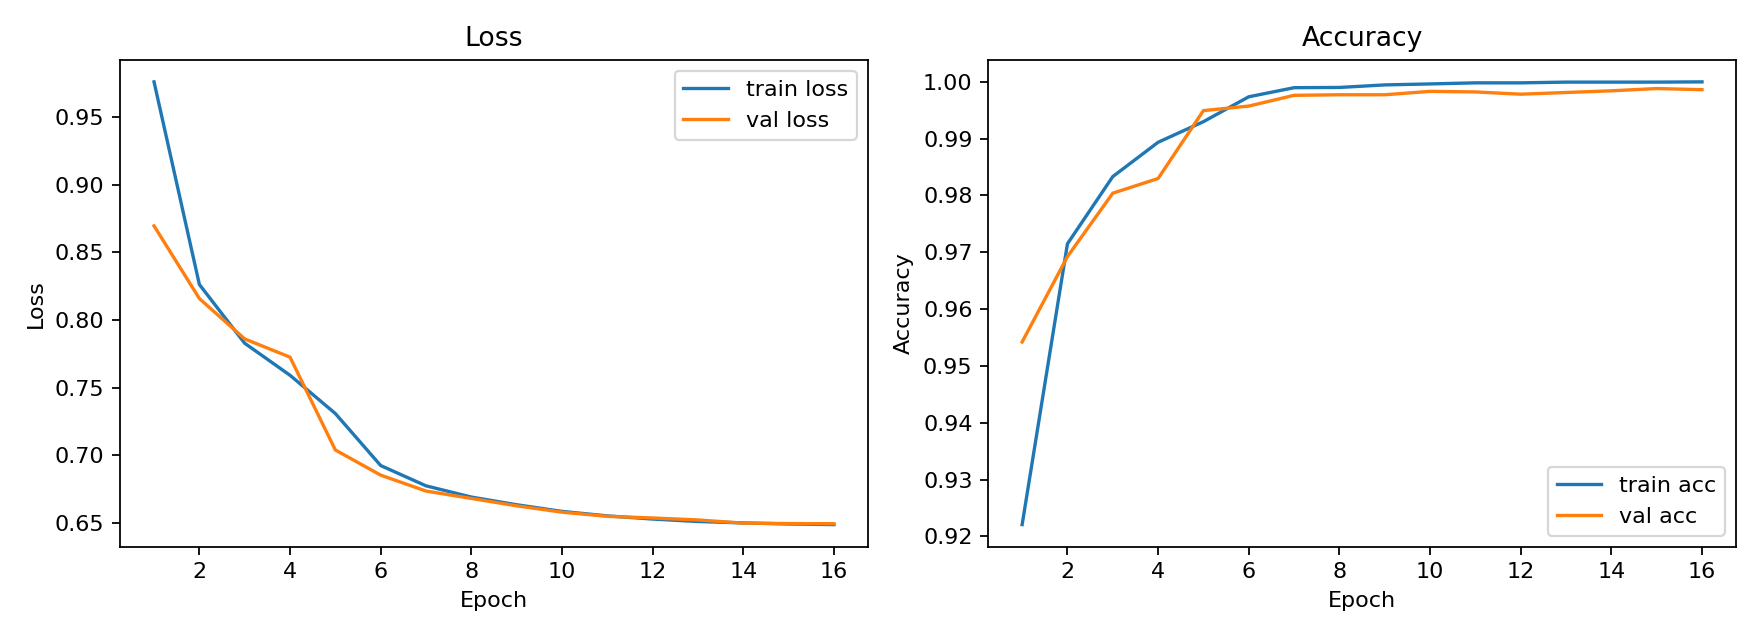

In [17]:
# 6- Save the best weights + learning curves
# Save best weight
BEST_WEIGHTS = RUN_DIR/"mobilenetv3_large_best.pth"
torch.save(best_state, BEST_WEIGHTS)
print("✅ Saved:", BEST_WEIGHTS)

# # Plot and save the learning curve
def plot_learning_curves(hist, out_path):
    epochs = range(1, len(hist["train_loss"])+1)
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"],   label="val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"],   label="val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=160); plt.close()

LC_PNG = RUN_DIR/"learning_curves.png"
plot_learning_curves(history, LC_PNG)
print("📈 Curves saved:", LC_PNG)

from IPython.display import Image, display
display(Image(filename="/content/plant_cls_runs/mobilenetv3_large_transfer/learning_curves.png"))


In [21]:
# Load best weights and evaluate on Test/Val set
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    logits_list, y_list = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        logits_list.append(logits.cpu())
        y_list.append(y)
    return torch.cat(logits_list,0), torch.cat(y_list,0)
#Downlode best wight
model.load_state_dict(torch.load(BEST_WEIGHTS, map_location="cpu"))
model.to(device)


eval_loader = test_loader if test_loader is not None else val_loader

logits_eval, y_true = predict_all(model, eval_loader)
probs_eval = torch.softmax(logits_eval, dim=1).numpy()
y_pred = probs_eval.argmax(1)
y_true = y_true.numpy()


In [27]:
# 7- Load the best weights + evaluate on Test + compute metrics
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Compute overall metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Print overall metrics
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

#  Generate a detailed report for each class
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=2,
    zero_division=0
)

# Print the report with clean formatting
print("📋 Classification Report:\n")
print(report)

# # Save it to a text file with the same formatting
report_path = RUN_DIR / "classification_report_formatted.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(f"Accuracy : {acc:.4f}\n")
    f.write(f"Precision: {prec:.4f}\n")
    f.write(f"Recall   : {rec:.4f}\n")
    f.write(f"F1-score : {f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print(f"🧾 Saved formatted report to: {report_path}")


Accuracy : 0.9987
Precision: 0.9987
Recall   : 0.9987
F1-score : 0.9987

📋 Classification Report:

                                     precision    recall  f1-score   support

                 Apple - Apple Scab       1.00      1.00      1.00       378
                  Apple - Black Rot       1.00      1.00      1.00       372
           Apple - Cedar Apple Rust       1.00      1.00      1.00       326
                    Apple - Healthy       1.00      1.00      1.00       375
       Bell Pepper - Bacterial Spot       1.00      1.00      1.00       358
              Bell Pepper - Healthy       1.00      1.00      1.00       372
                   Cherry - Healthy       1.00      1.00      1.00       343
            Cherry - Powdery Mildew       1.00      1.00      1.00       315
Corn (Maize) - Cercospora Leaf Spot       0.99      0.99      0.99       308
         Corn (Maize) - Common Rust       1.00      1.00      1.00       357
             Corn (Maize) - Healthy       1.00      1

🧩 CM saved: /content/plant_cls_runs/mobilenetv3_large_transfer/confusion_matrix.png


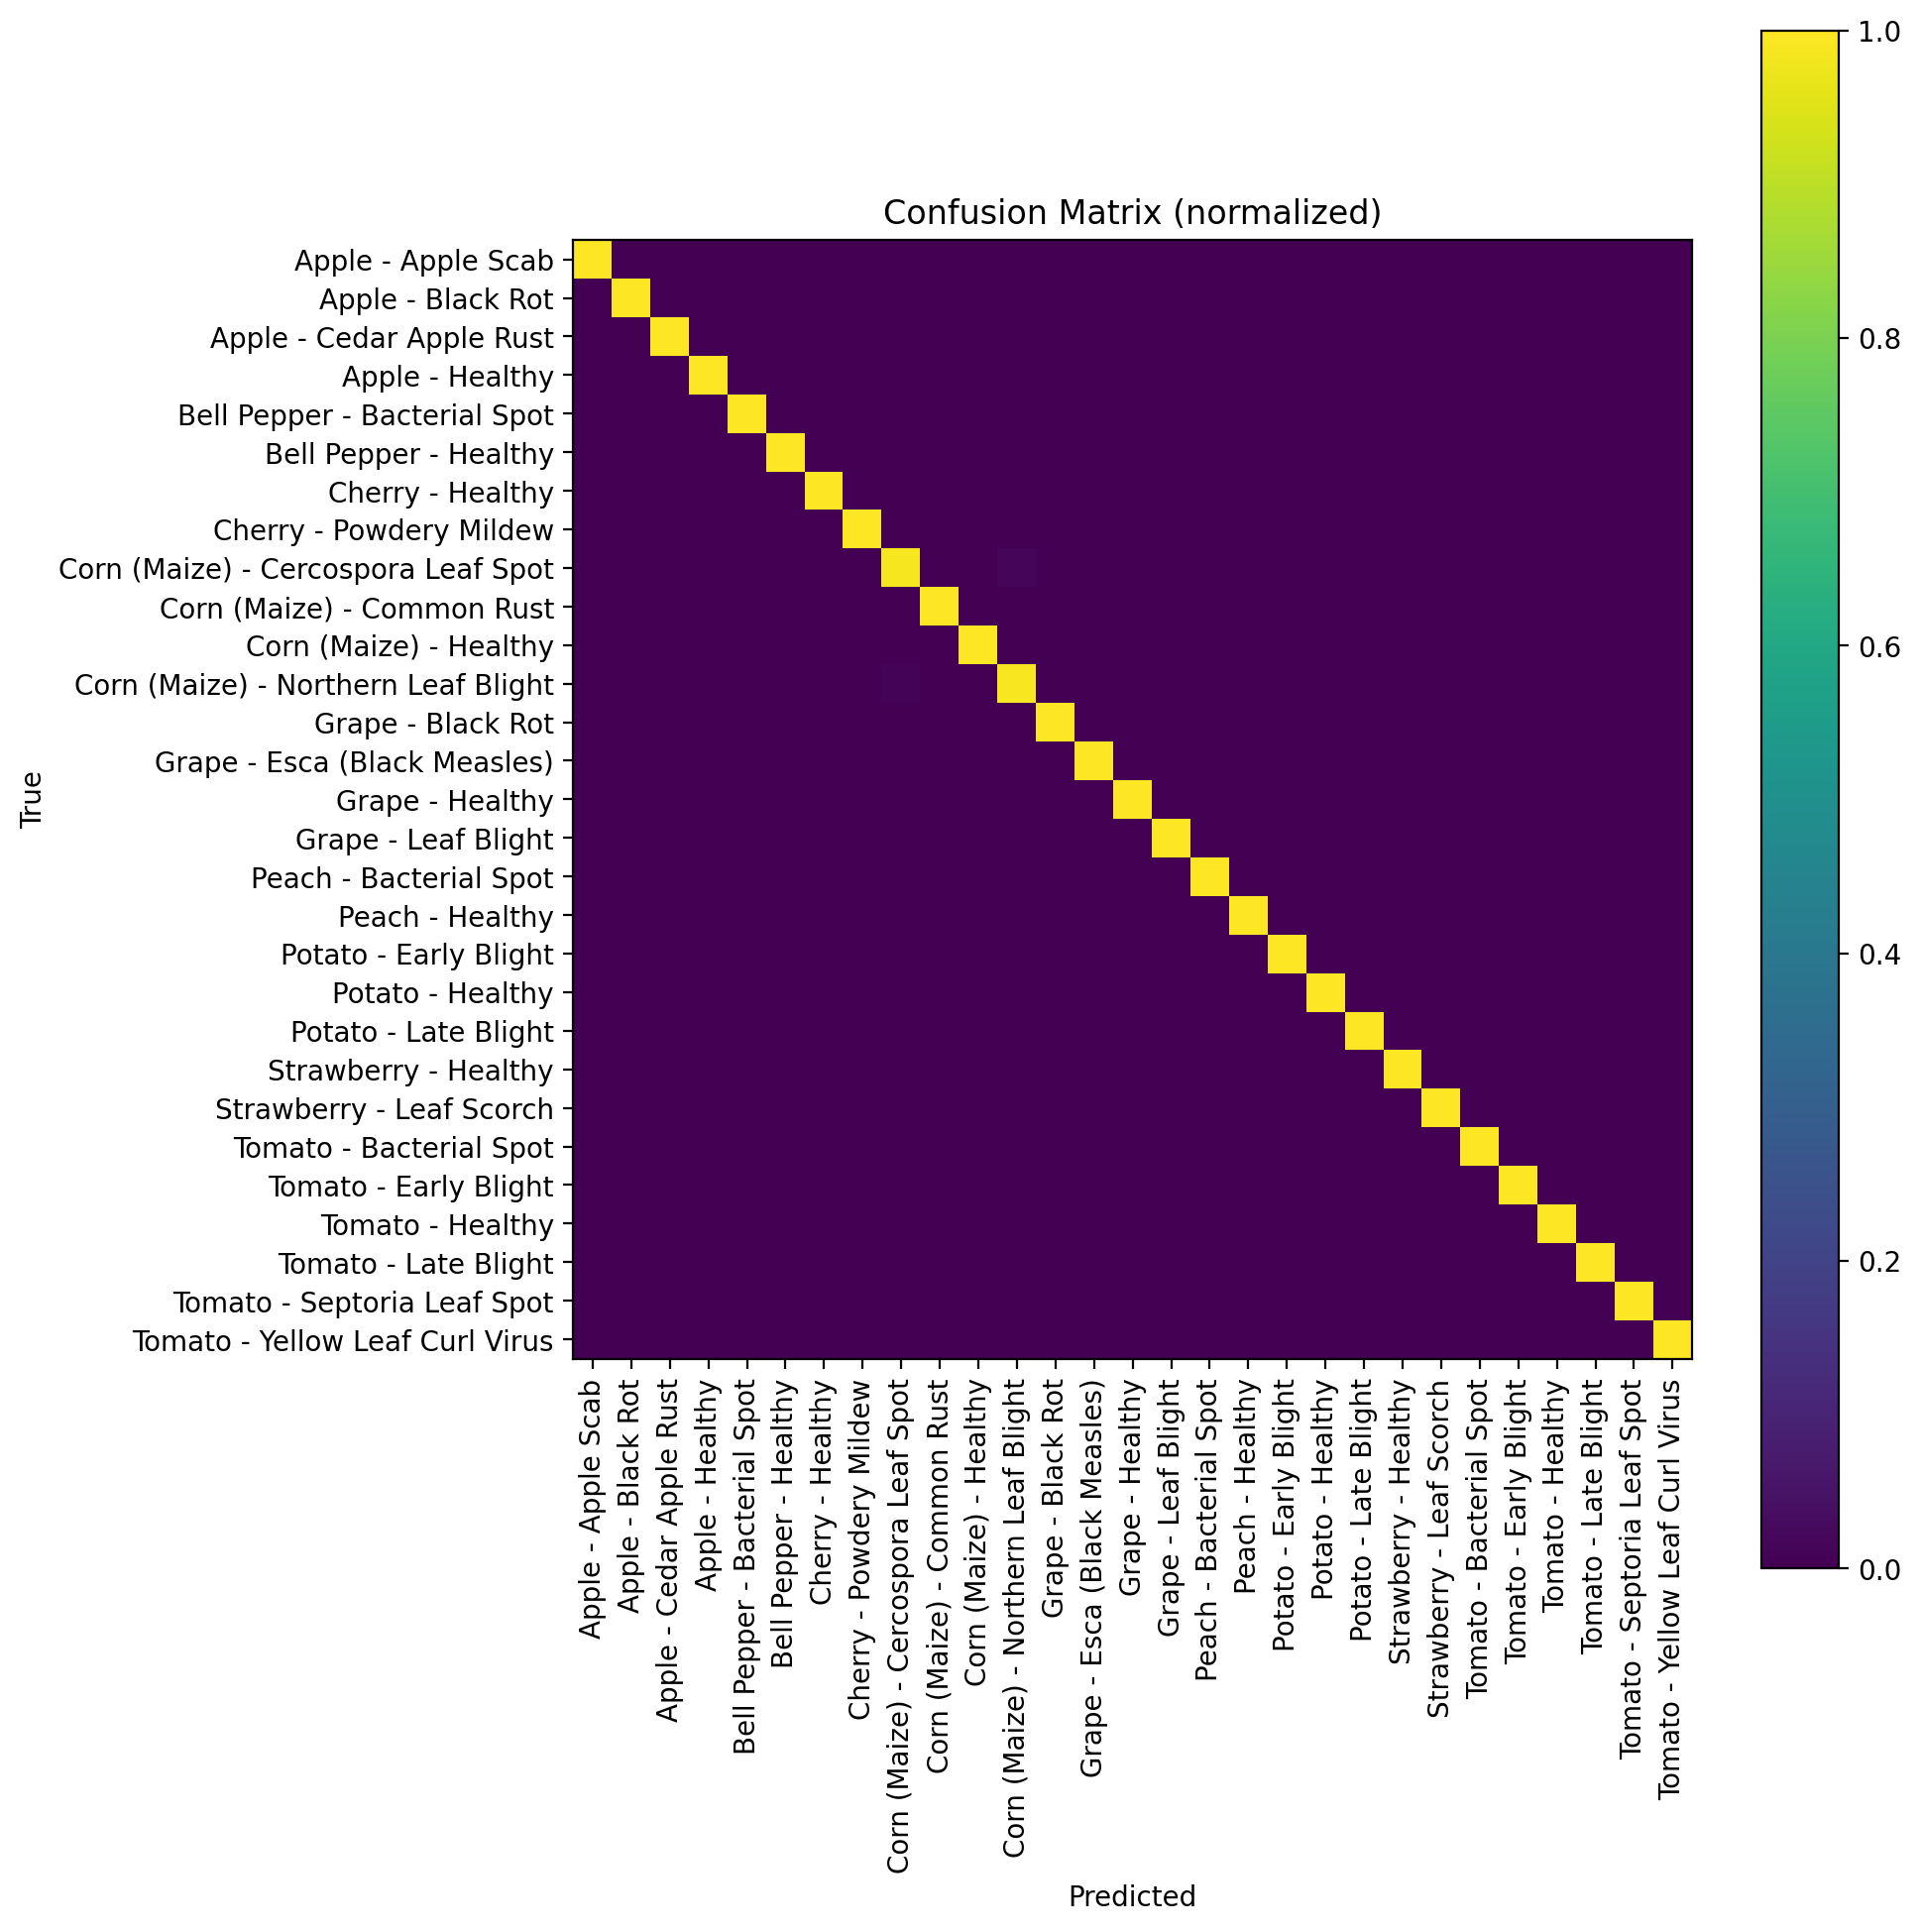

In [22]:
# 8- Plot and save the Confusion Matrix (normalized)
import numpy as np
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig = plt.figure(figsize=(max(8, num_classes*0.35), max(6, num_classes*0.35)))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Confusion Matrix (normalized)"); plt.colorbar()
ticks = np.arange(num_classes)
plt.xticks(ticks, class_names, rotation=90)
plt.yticks(ticks, class_names)
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
CM_PNG = RUN_DIR/"confusion_matrix.png"
plt.savefig(CM_PNG, dpi=200, bbox_inches="tight"); plt.close()
print("🧩 CM saved:", CM_PNG)
from IPython.display import Image, display
display(Image(filename="/content/plant_cls_runs/mobilenetv3_large_transfer/confusion_matrix.png"))



ROC saved: /content/plant_cls_runs/mobilenetv3_large_transfer/roc_macro.png


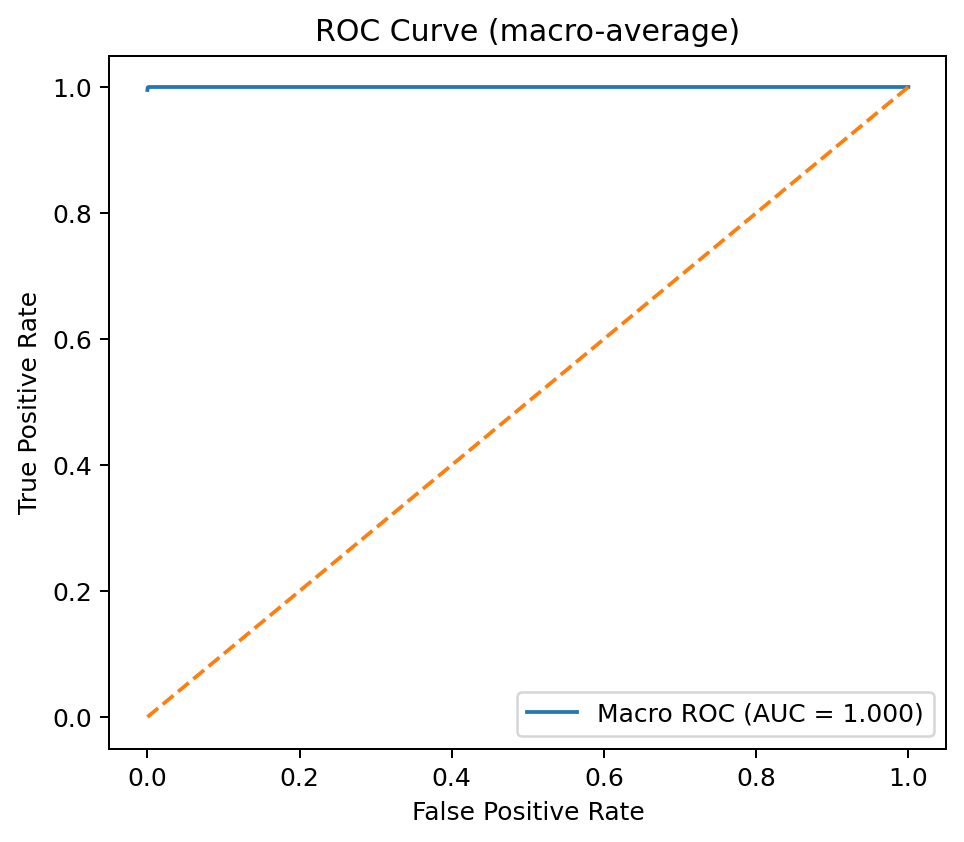

In [26]:

# 9- Plot and save the ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Binarize labels
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

fpr, tpr = {}, {}

# Compute ROC for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs_eval[:, i])

# Collect all FPR values
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

# Interpolate TPR values
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

# Compute macro AUC
macro_auc = auc(all_fpr, mean_tpr)

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(all_fpr, mean_tpr, label=f"Macro ROC (AUC = {macro_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (macro-average)")
plt.legend(loc="lower right")

ROC_PNG = RUN_DIR/"roc_macro.png"
plt.savefig(ROC_PNG, dpi=180, bbox_inches="tight")
plt.close()

print("ROC saved:", ROC_PNG)

from IPython.display import Image, display
display(Image(filename=str(ROC_PNG)))


In [29]:
!ls /content/plant_cls_runs/mobilenetv3_large_transfer/

classification_report_formatted.txt  learning_curves.png
confusion_matrix.png		     mobilenetv3_large_best.pth
label_map.json			     roc_macro.png


Predict the diseases for the new image

In [30]:
#  Upload an image (or multiple images) from your device
from google.colab import files
uploaded = files.upload()
file_list = list(uploaded.keys())
file_list


Saving CornCommonRust3.jpg to CornCommonRust3.jpg


['CornCommonRust3.jpg']

In [31]:
import json
from pathlib import Path
import torch, torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Saving paths used during training
RUN_DIR = Path("/content/plant_cls_runs/mobilenetv3_large_transfer")
BEST_WEIGHTS = RUN_DIR / "mobilenetv3_large_best.pth"
LABEL_MAP = RUN_DIR / "label_map.json"

# Load class names in the same order as during training
label_map = json.loads(LABEL_MAP.read_text(encoding="utf-8"))
idx2name = {int(k): v for k, v in label_map.items()}
num_classes = len(idx2name)

#Build MobileNetV3-Large with the same training modification
model = models.mobilenet_v3_large(weights=None)
model.classifier[2] = nn.Dropout(p=0.25)           # نفس الدروب آوت الذي استخدمناه
model.classifier[3] = nn.Linear(1280, num_classes) # آخر طبقة بعدد أصنافك
state = torch.load(BEST_WEIGHTS, map_location="cpu")
model.load_state_dict(state)
model.eval().to(device)

#Evaluation transforms (ImageNet)
IMG_SIZE = 224
eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])


→ CornCommonRust3.jpg


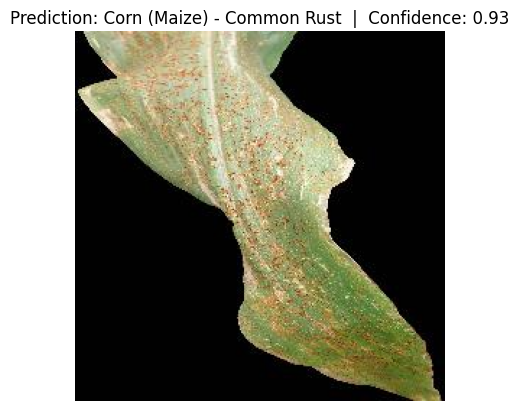

In [32]:
@torch.no_grad()
def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0].cpu()
    top1_id = int(torch.argmax(probs))
    top1_name = idx2name[top1_id]
    top1_conf = float(probs[top1_id])

    #Display the image and the prediction title
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {top1_name}  |  Confidence: {top1_conf:.2f}")
    plt.show()
    return top1_name, top1_conf

#Try the first file or all uploaded files
for fp in file_list:
    print("→", fp)
    predict_image(fp)